In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
np.random.seed(0)

In [8]:
n = 100 # Define n as the number of students
df = pd.DataFrame({
    "Student_ID": range(1, n+1),
    "Name": [f"Student_{i}" for i in range(1, n+1)],
    "Gender": np.random.choice(["Male", "Female"], n),
    "Department": np.random.choice(["CSE", "IT", "ECE"], n),
    "Year": np.random.choice(["1st", "2nd", "3rd"], n),
    "Maths": np.random.randint(35, 100, n),
    "Science": np.random.randint(35, 100, n),
    "English": np.random.randint(35, 100, n),
    "Attendance": np.random.randint(50, 101, n),
    "Internal_Marks": np.random.randint(0, 26, n)
})

In [9]:
print(df.isnull().sum())

# 3. Feature Engineering
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 85:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 50:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)


Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
dtype: int64


In [10]:
print(df.describe())


       Student_ID       Maths     Science     English  Attendance  \
count  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    50.500000   67.350000   66.550000   65.810000   74.390000   
std     29.011492   18.064629   19.222974   18.208498   15.418011   
min      1.000000   35.000000   35.000000   36.000000   50.000000   
25%     25.750000   53.000000   47.750000   51.750000   61.750000   
50%     50.500000   65.000000   69.000000   65.000000   74.500000   
75%     75.250000   84.000000   81.250000   81.250000   87.250000   
max    100.000000   99.000000   98.000000   99.000000  100.000000   

       Internal_Marks       Total     Average  
count       100.00000  100.000000  100.000000  
mean         12.07000  199.710000   66.570000  
std           7.36118   32.532903   10.844301  
min           0.00000  122.000000   40.666667  
25%           5.00000  180.750000   60.250000  
50%          12.00000  201.000000   67.000000  
75%          18.25000  222.500000   74.166

In [11]:
top_students = df.sort_values(by="Average", ascending=False).head(5)
fail_students = df[df["Grade"] == "Fail"]

print("\nTop Students:\n", top_students)
print("\nFail Students:\n", fail_students)


Top Students:
     Student_ID        Name  Gender Department Year  Maths  Science  English  \
64          65  Student_65  Female        ECE  2nd     78       92       99   
69          70  Student_70    Male        CSE  2nd     83       92       83   
62          63  Student_63  Female        ECE  3rd     88       80       81   
21          22  Student_22  Female        CSE  3rd     98       70       80   
36          37  Student_37    Male         IT  3rd     60       95       92   

    Attendance  Internal_Marks  Total    Average Grade  
64          91              17    269  89.666667     A  
69          90              16    258  86.000000     A  
62          78               8    249  83.000000     B  
21          86              17    248  82.666667     B  
36          56               7    247  82.333333     B  

Fail Students:
     Student_ID        Name  Gender Department Year  Maths  Science  English  \
11          12  Student_12    Male        ECE  1st     52       55     

In [12]:
print("\nDepartment-wise:\n", df.groupby("Department")["Average"].mean())
print("\nGender-wise:\n", df.groupby("Gender")["Average"].mean())
print("\nYear-wise:\n", df.groupby("Year")["Average"].mean())


Department-wise:
 Department
CSE    66.179487
ECE    66.074074
IT     67.893333
Name: Average, dtype: float64

Gender-wise:
 Gender
Female    66.369048
Male      66.825758
Name: Average, dtype: float64

Year-wise:
 Year
1st    64.606061
2nd    66.615385
3rd    68.821429
Name: Average, dtype: float64


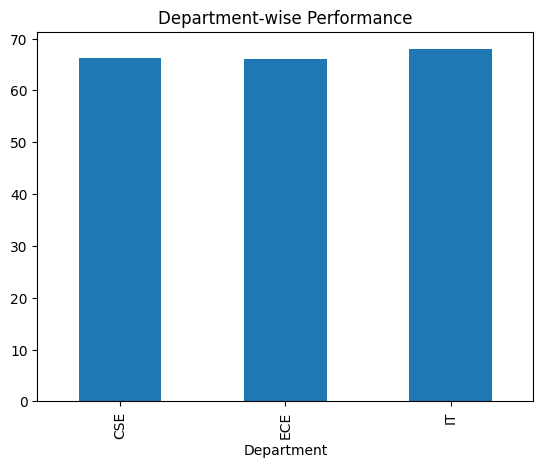

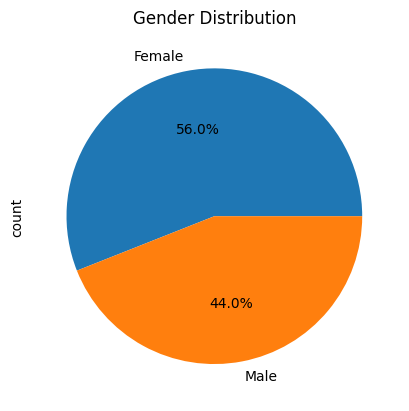

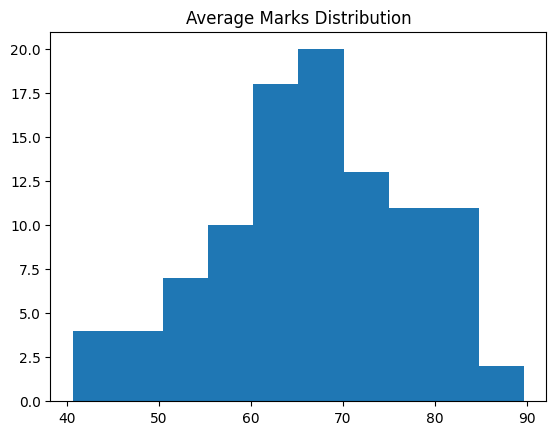

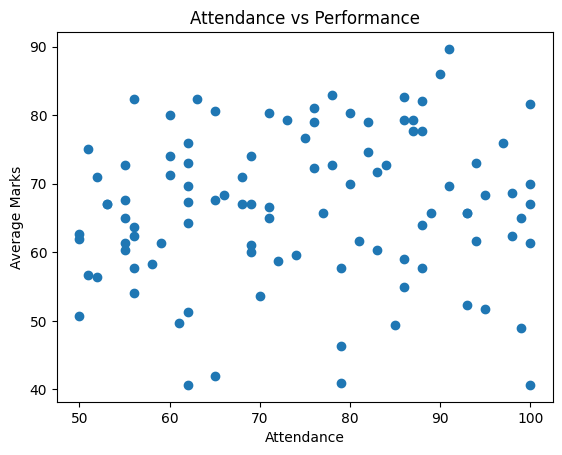

In [14]:
df.groupby("Department")["Average"].mean().plot(kind="bar")
plt.title("Department-wise Performance")
plt.show()


df["Gender"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

plt.hist(df["Average"])
plt.title("Average Marks Distribution")
plt.show()

plt.scatter(df["Attendance"], df["Average"])
plt.title("Attendance vs Performance")
plt.xlabel("Attendance")
plt.ylabel("Average Marks")
plt.show()